# Dataset

Lista de puntajes obtenidos por diferentes jugadores oficialmente reconocidos por la Federación Internacional de Ajedrez. Los puntajes son mensuales y se cuenta con información de todos los meses del 2025. Se han considerado solo los puntajes del modo de juego "Blitz".

Fuente: https://ratings.fide.com/download_lists.phtml

Se descargaron 12 archivos XML con los puntajes, que luego fueron integrados en 1 solo archivo (Ver obtencion.py).

In [1]:
import pandas as pd

df = pd.read_csv('data/combined.csv')

# Data profiling

## Estructura del dataset

Se cuenta con 14 variables y 3 149 829 de observaciones. Hay variables de tipo numérico y cadena de texto.

|Name|Type|Description|
|---|---|---|
|fideid|Int|identification number of a player within FIDE database|
|name|str|name of a player|
|country|str|Federation of a player|
|sex|str|sex of a player|
|title|str|title of a player|
|w_title|str|TBD|
|o_title|str|Other titles of a player|
|foa_title|str|TBD|
|rating|Int|Blitz Rating|
|games|Int|number of BLITZ rating games in given period|
|k|Int|BLITZ rating K factor|
|birthday|float|year of birth of a player|
|flag|str|flag of inactivity|
|filename|str|name of the file that holds the data for the month|



## Calidad del dataset

describir la calidad en términos de (al menos) completitud, unicidad, validez y consistencia. Se sugiere que use tablas para justificar sus comentarios (pueden ser screenshots de su notebook). [2-4 líneas de texto por sección  + equivalente a 10 líneas por imagen]

### Completitud

Se puede ver altos niveles de valores perdidos en las columnas con información de títulos obtenidos por los jugadores, con 93.78% de valores perdidos en "title", y alrededor de 98% para el resto de columnas de títulos. También se ve que la columna "flag" contiene un 34.64% de valores perdidos, lo que puede indicar que la información ha sido incorrectamente codificada. Por último, se ve que el 1.13% de observaciones no cuenta con información de "birthday". 

In [6]:
# get count and percentage of missing data for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
# create a dataframe to display the results
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Missing Percentage': missing_percentage})
print(missing_df)


            Missing Count  Missing Percentage
Unnamed: 0              0            0.000000
fideid                  0            0.000000
name                    0            0.000000
country                 0            0.000000
sex                     0            0.000000
title             2954110           93.786331
w_title           3110641           98.755838
o_title           3114808           98.888130
foa_title         3091700           98.154504
rating                  0            0.000000
games                   0            0.000000
k                       0            0.000000
birthday            35751            1.135014
flag              1091180           34.642505
filename                0            0.000000


### Unicidad

In [7]:
# count duplicates across all columnas, with exception of filename
duplicate_count = df.drop(columns=['filename']).duplicated().sum()
print(f'Number of duplicate rows (excluding filename): {duplicate_count}')

Number of duplicate rows (excluding filename): 0


In [9]:
# count duplicates across all columnas, with exception of filename, k and flag
duplicate_count_k_flag = df.drop(columns=['filename', 'k', 'flag']).duplicated().sum()
print(f'Number of duplicate rows (excluding filename, k and flag): {duplicate_count_k_flag}')

Number of duplicate rows (excluding filename, k and flag): 0


In [10]:
# Summary of data quality findings
print(f'Dataset shape: {df.shape}')
print(f'Total rows: {len(df):,}')
print(f'Total columns: {len(df.columns)}')
print(f'\nData quality summary:')
print(f'- Missing values: {missing_data.sum()}')
print(f'- Duplicates (excl. filename): {duplicate_count}')
print(f'- Duplicates (excl. filename, k): {duplicate_count_k}')
print(f'- Duplicates (excl. filename, k, flag): {duplicate_count_k_flag}')

Dataset shape: (3149830, 15)
Total rows: 3,149,830
Total columns: 15

Data quality summary:
- Missing values: 13398190
- Duplicates (excl. filename): 0
- Duplicates (excl. filename, k): 0
- Duplicates (excl. filename, k, flag): 0


In [11]:
# count unique fideid values
unique_fideid_count = df['fideid'].nunique()
print(f'Number of unique fideid values: {unique_fideid_count}')

Number of unique fideid values: 283291


In [12]:
# count duplicates of the combination of fideid and flag
duplicate_fideid_flag_count = df.duplicated(subset=['fideid', 'flag']).sum()
print(f'Number of duplicate rows based on fideid and flag: {duplicate_fideid_flag_count}')


Number of duplicate rows based on fideid and flag: 2808353


In [13]:
# count all values of flag
flag_counts = df['flag'].value_counts(dropna=False)
print('Flag value counts:')
print(flag_counts)

Flag value counts:
flag
i      1711833
NaN    1091180
wi      204416
w       142401
Name: count, dtype: int64


In [15]:
# count all rows where games is not zero
non_zero_games_count = (df['games'] != 0).sum()
print(f'Number of rows where games is not zero: {non_zero_games_count}')

Number of rows where games is not zero: 224393


<Axes: xlabel='games', ylabel='Count'>

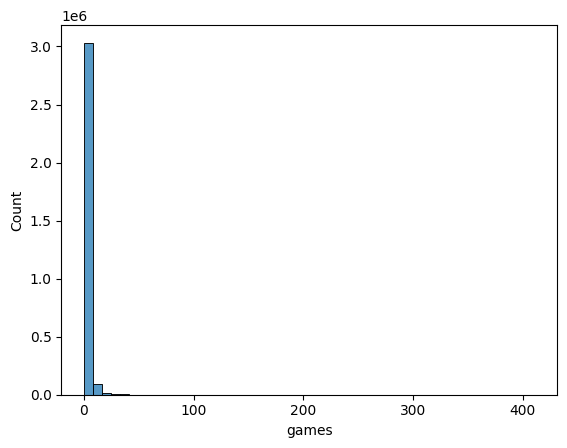

In [16]:
# histogram of games with seaborn
import seaborn as sns
sns.histplot(df['games'], bins=50, kde=False)

